In [33]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import numpy as np


from sandbox.plt_dict import matplotlib_update
matplotlib_update()

def plot_model_results(folder_path, epsilons, d_train, kl_plot=True, acc_plot=True, acc_pm_plot=True, acc_within=2, plot_filename=""):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None, 'acc_pm': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])

                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t)<=acc_within) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc
                    data[curr_eps][d]['acc_pm'] = acc_pm

    # 2. Preparation for Plotting
    sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
    # --- FIGURE 1: KL Loss ---
    if kl_plot:
        plt.figure()
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            kl_vals = [data[eps][d]['kl'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, kl_vals, marker='o', label=label)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, which='both', linestyle=':', alpha=0.5)
        plt.tight_layout()

        if plot_filename:
            plt.savefig(plot_filename + "_loss.pdf")

    # --- FIGURE 2: Accuracy ---
    if acc_plot:
        plt.figure()
        sorted_ds = sorted(data[sorted_eps[0]].keys())
        d_min = sorted_ds[0]
        d_max = sorted_ds[-1]
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            acc_vals = [data[eps][d]['acc'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, acc_vals, marker='s', label=label)

        # plt.plot(d_grid := range(d_min, d_max+1), [1/d for d in d_grid], ':', color='black', alpha=0.6)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        if plot_filename:
            plt.savefig(plot_filename + "_accuracy.pdf")

        plt.show()

    # --- FIGURE 3: Accuracy within ---
    if acc_pm_plot:
        plt.figure()
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            acc_vals = [data[eps][d]['acc_pm'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, acc_vals, marker='s', label=label)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel(f"Accuracy@$\\pm${acc_within}")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        if plot_filename:
            plt.savefig(plot_filename + f"_accuracy_at_{acc_within}.pdf")

        plt.show()

In [34]:
def model_results_to_pandas(folder_path, epsilons, d_train, acc_within=2):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None, 'acc_pm': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])

                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t)<=acc_within) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc
                    data[curr_eps][d]['acc_pm'] = acc_pm

    df = pd.DataFrame.from_dict({(i, j): data[i][j] 
                        for i in data.keys() 
                        for j in data[i].keys()},
                    orient='index')

    # 2. Extract your three DataFrames
    # We unstack 'level 0' (which is 'eps') to move it to the columns
    df_kl = df['kl'].unstack(level=0)
    df_acc = df['acc'].unstack(level=0)
    df_acc_pm = df['acc_pm'].unstack(level=0)
    return df_kl, df_acc, df_acc_pm

In [35]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

In [36]:
df_kl, df_acc, df_acc_pm = model_results_to_pandas('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2], pretrained_dimensions)

In [37]:
df_kl.round(decimals=2)

,0.000000,0.000001,0.000100,0.010000
4,0.06,0.04,0.59,0.31
6,0.06,0.13,0.73,0.29
7,0.22,0.06,0.69,0.31
9,0.11,0.19,0.42,0.34
12,0.29,0.04,0.53,0.47
13,0.77,0.07,0.58,0.69
15,0.30,0.33,0.15,0.63
19,0.95,0.06,0.49,1.11
23,0.85,0.13,0.40,1.57
25,1.07,0.11,0.67,1.78


In [38]:
df_kl_mod = df_kl.div(np.log(df_kl.index), axis=0)

In [39]:
df_kl_mod

,0.000000,0.000001,0.000100,0.010000
4,0.044004,0.028435,0.428942,0.222450
6,0.031283,0.070937,0.405068,0.160203
7,0.112686,0.031292,0.354722,0.157303
9,0.051196,0.088175,0.189635,0.153350
12,0.116650,0.015915,0.211460,0.187761
13,0.299363,0.025932,0.227136,0.267108
15,0.110444,0.121725,0.055457,0.232283
19,0.322161,0.019090,0.167368,0.378264
23,0.269753,0.042704,0.126758,0.500634
25,0.333050,0.033082,0.209173,0.553883


In [40]:
df_kl_mod = df_kl.div(df_kl.index, axis=0)

In [42]:
df_kl_mod

,0.000000,0.000001,0.000100,0.010000
4,0.015251,0.009855,0.148660,0.077095
6,0.009342,0.021184,0.120964,0.047841
7,0.031325,0.008699,0.098608,0.043728
9,0.012499,0.021527,0.046297,0.037438
12,0.024155,0.003296,0.043788,0.038881
13,0.059065,0.005116,0.044815,0.052702
15,0.019939,0.021976,0.010012,0.041936
19,0.049926,0.002958,0.025937,0.058620
23,0.036774,0.005822,0.017280,0.068249
25,0.042882,0.004259,0.026932,0.071315


In [43]:
df_acc.round(decimals=3)

,0.000000,0.000001,0.000100,0.010000
4,1.000,1.000,0.997,0.644
6,0.999,1.000,0.999,0.779
7,0.961,0.999,0.992,0.638
9,0.999,1.000,0.994,0.676
12,0.918,0.999,0.944,0.465
13,0.673,0.991,0.972,0.415
15,0.895,0.998,0.994,0.480
19,0.560,0.995,0.967,0.298
23,0.683,0.992,0.903,0.284
25,0.545,0.985,0.888,0.201


In [24]:
df_acc_pm.round(decimals=3)

,0.000000,0.000001,0.000100,0.010000
4,1.000,1.0,1.000,1.000
6,1.000,1.0,1.000,0.999
7,1.000,1.0,1.000,0.997
9,1.000,1.0,1.000,0.989
12,1.000,1.0,1.000,0.958
13,0.991,1.0,1.000,0.939
15,1.000,1.0,1.000,0.945
19,0.977,1.0,1.000,0.821
23,0.996,1.0,1.000,0.763
25,0.973,1.0,1.000,0.717


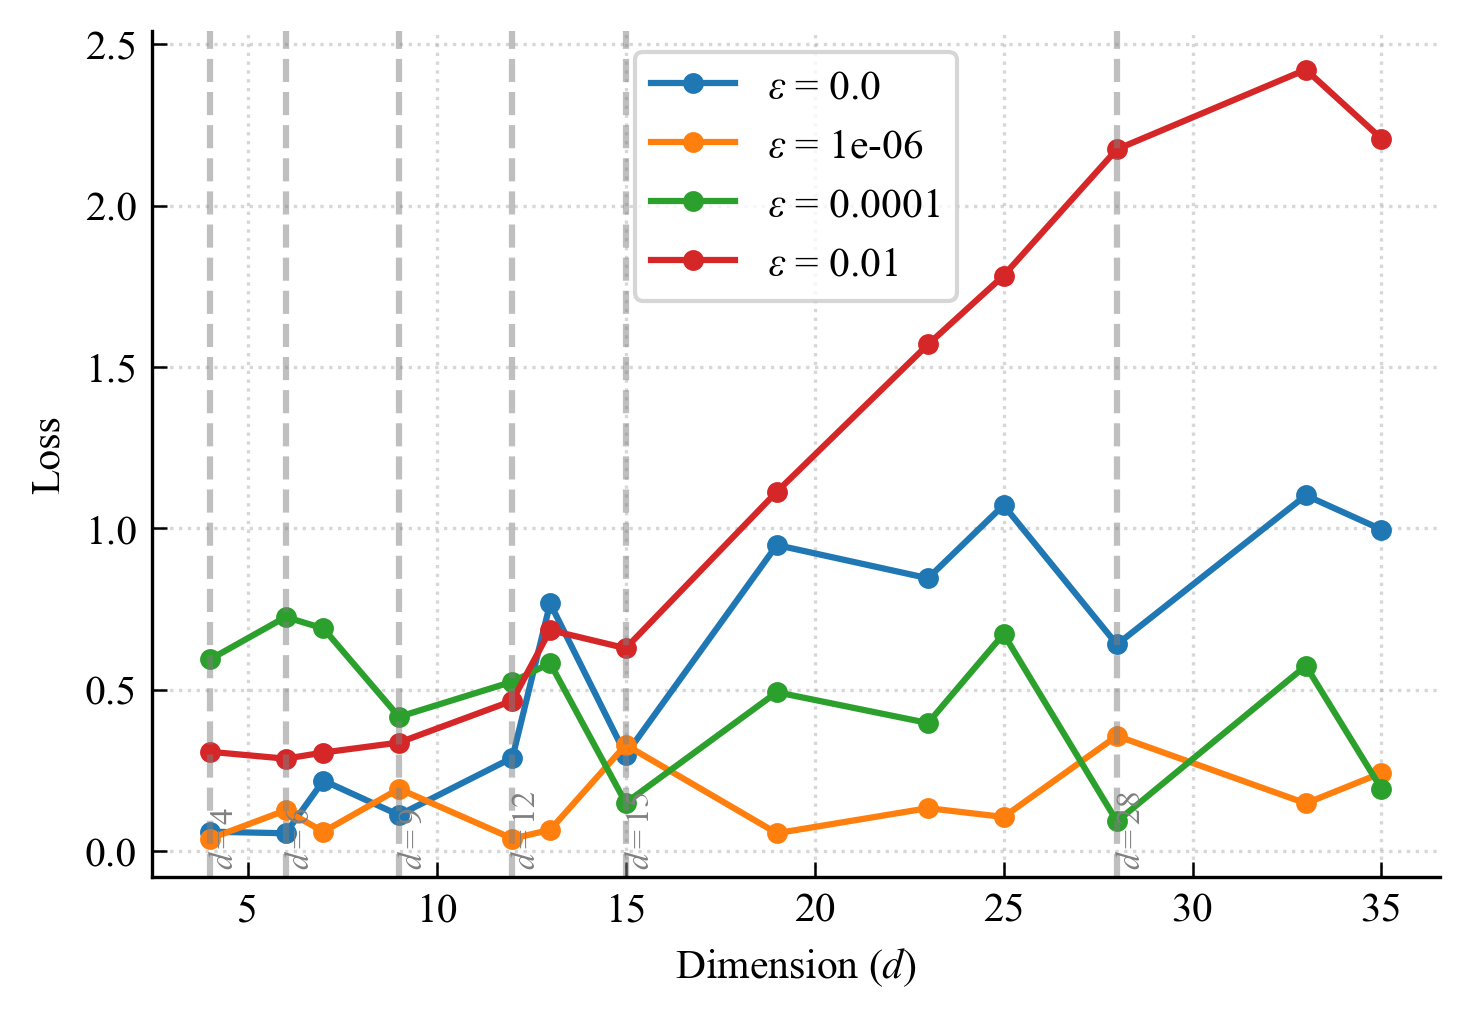

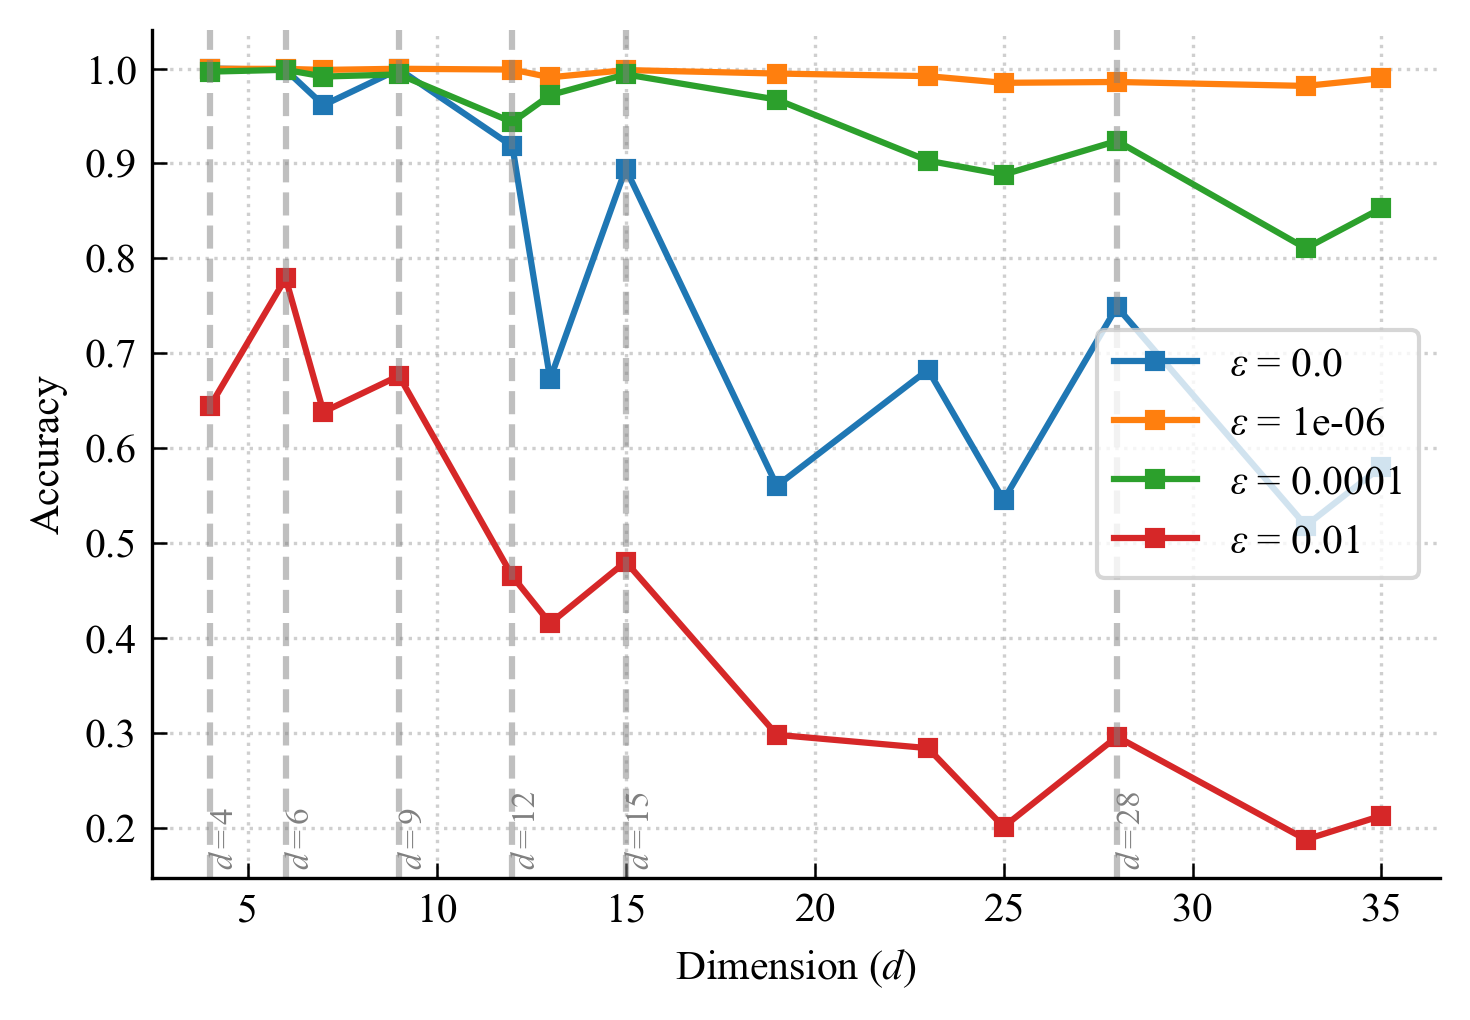

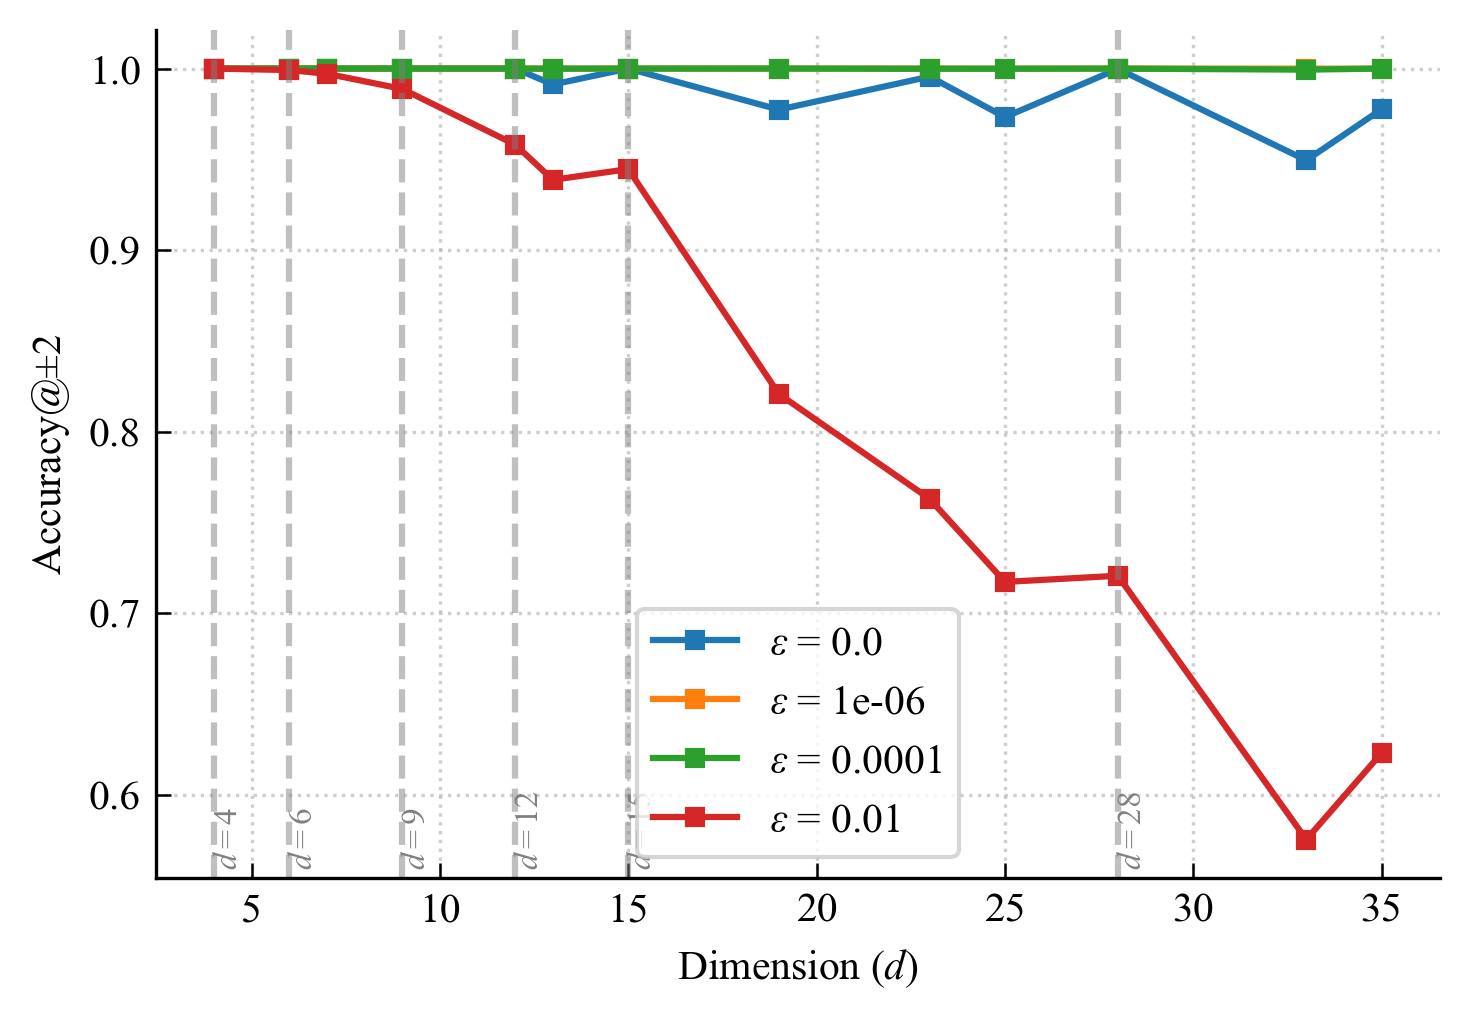

In [11]:
plot_model_results('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2], pretrained_dimensions, plot_filename="latex/images/j8_a", kl_plot=True, acc_pm_plot=True)

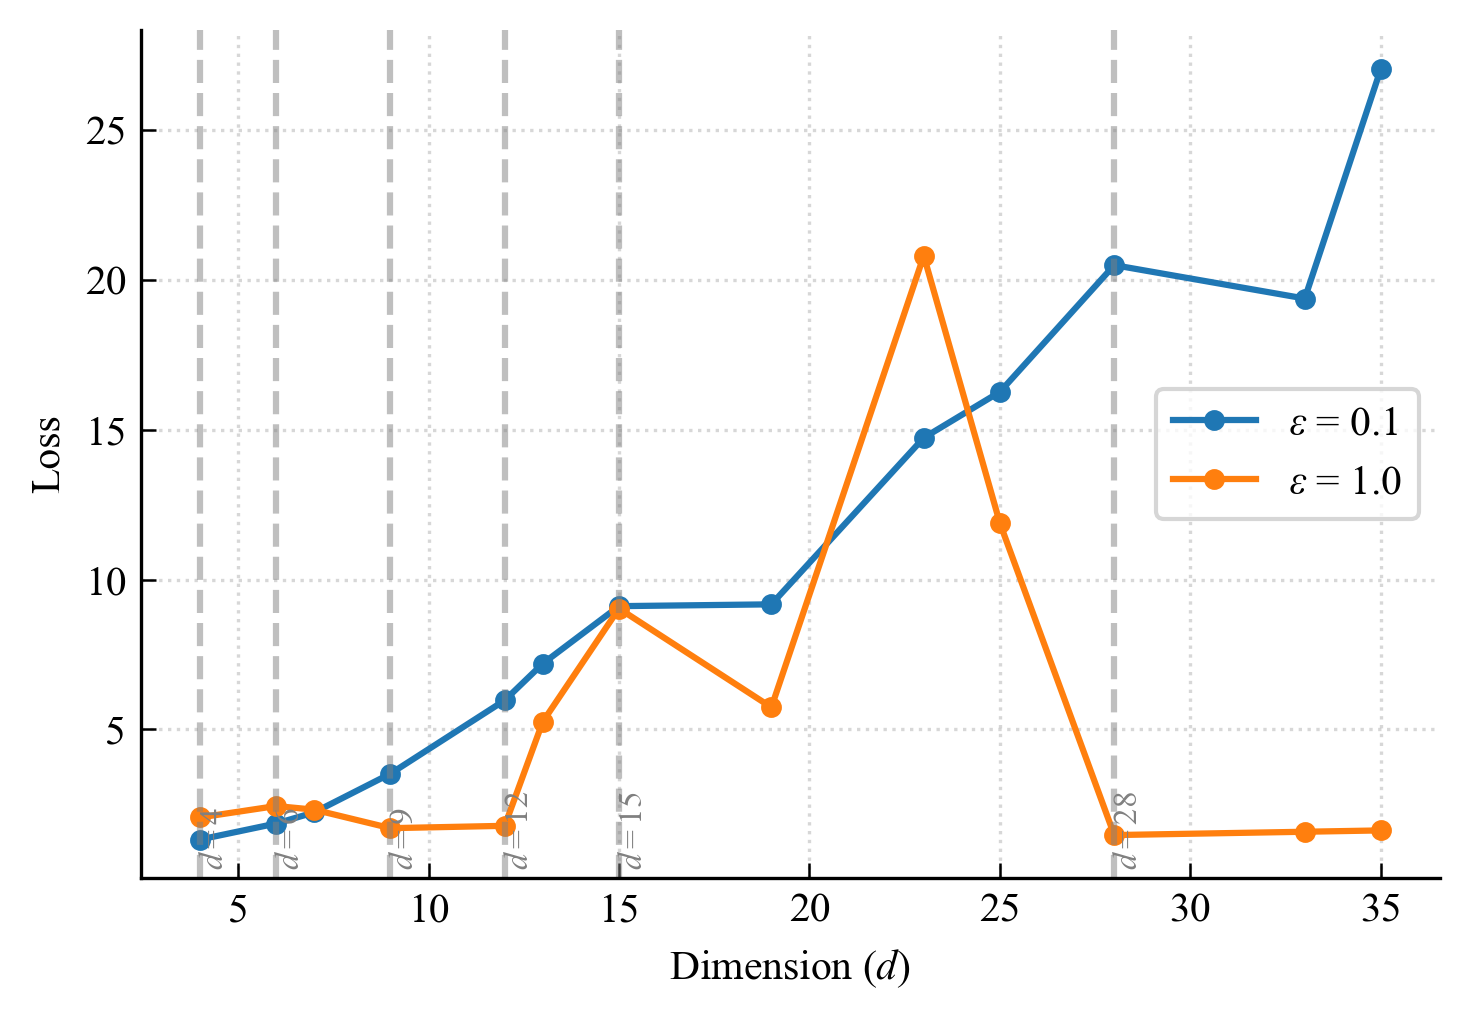

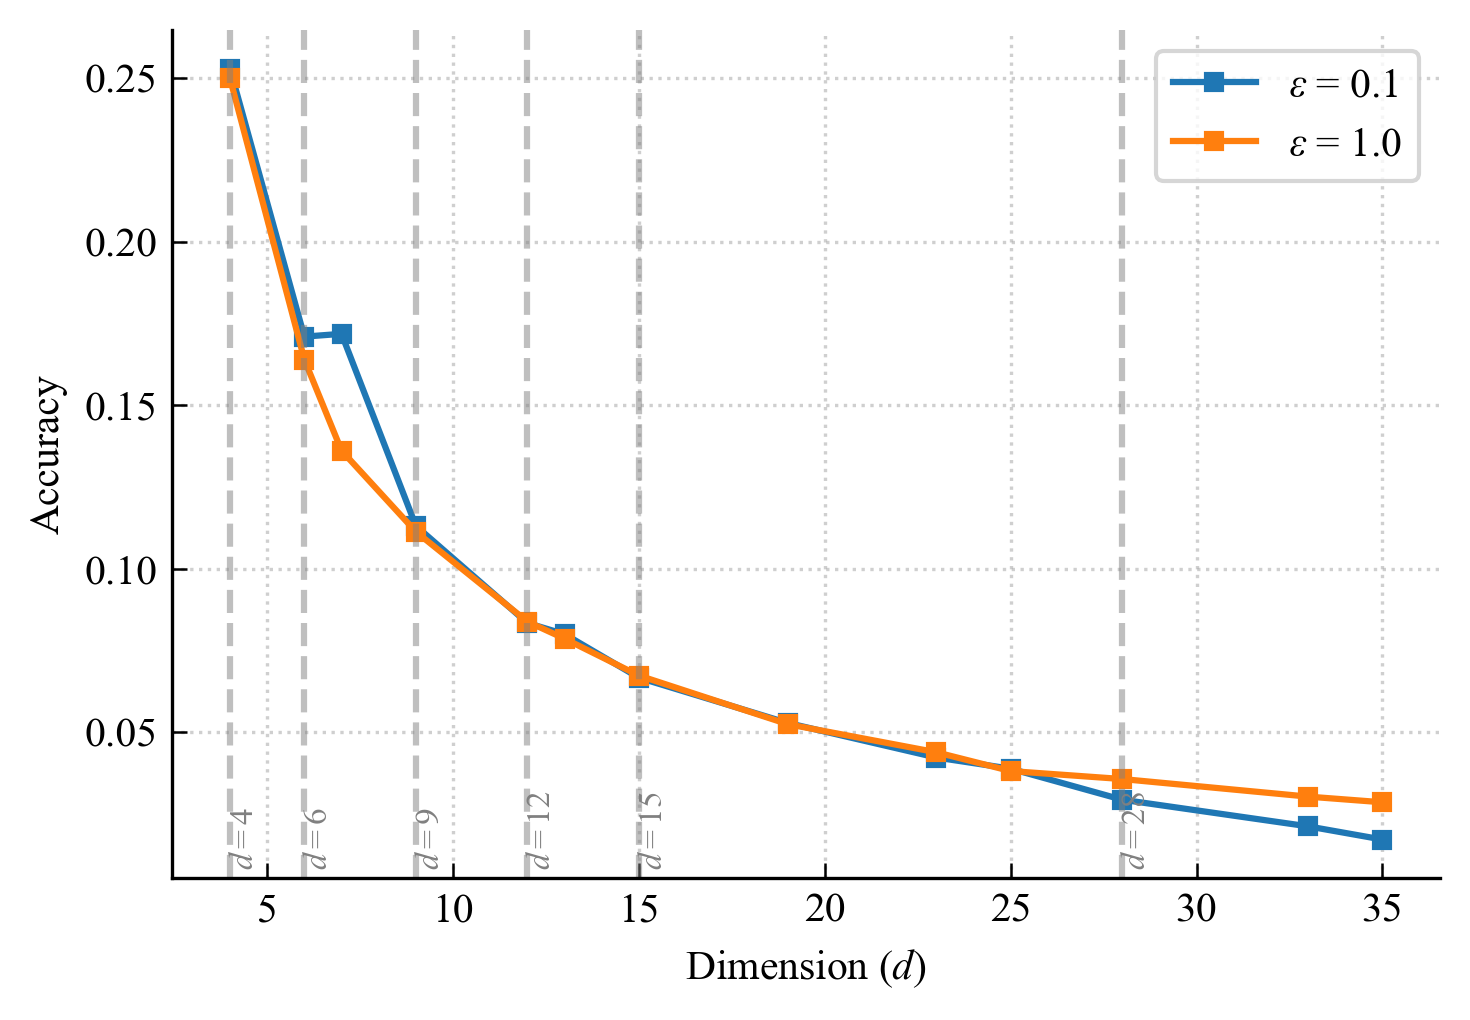

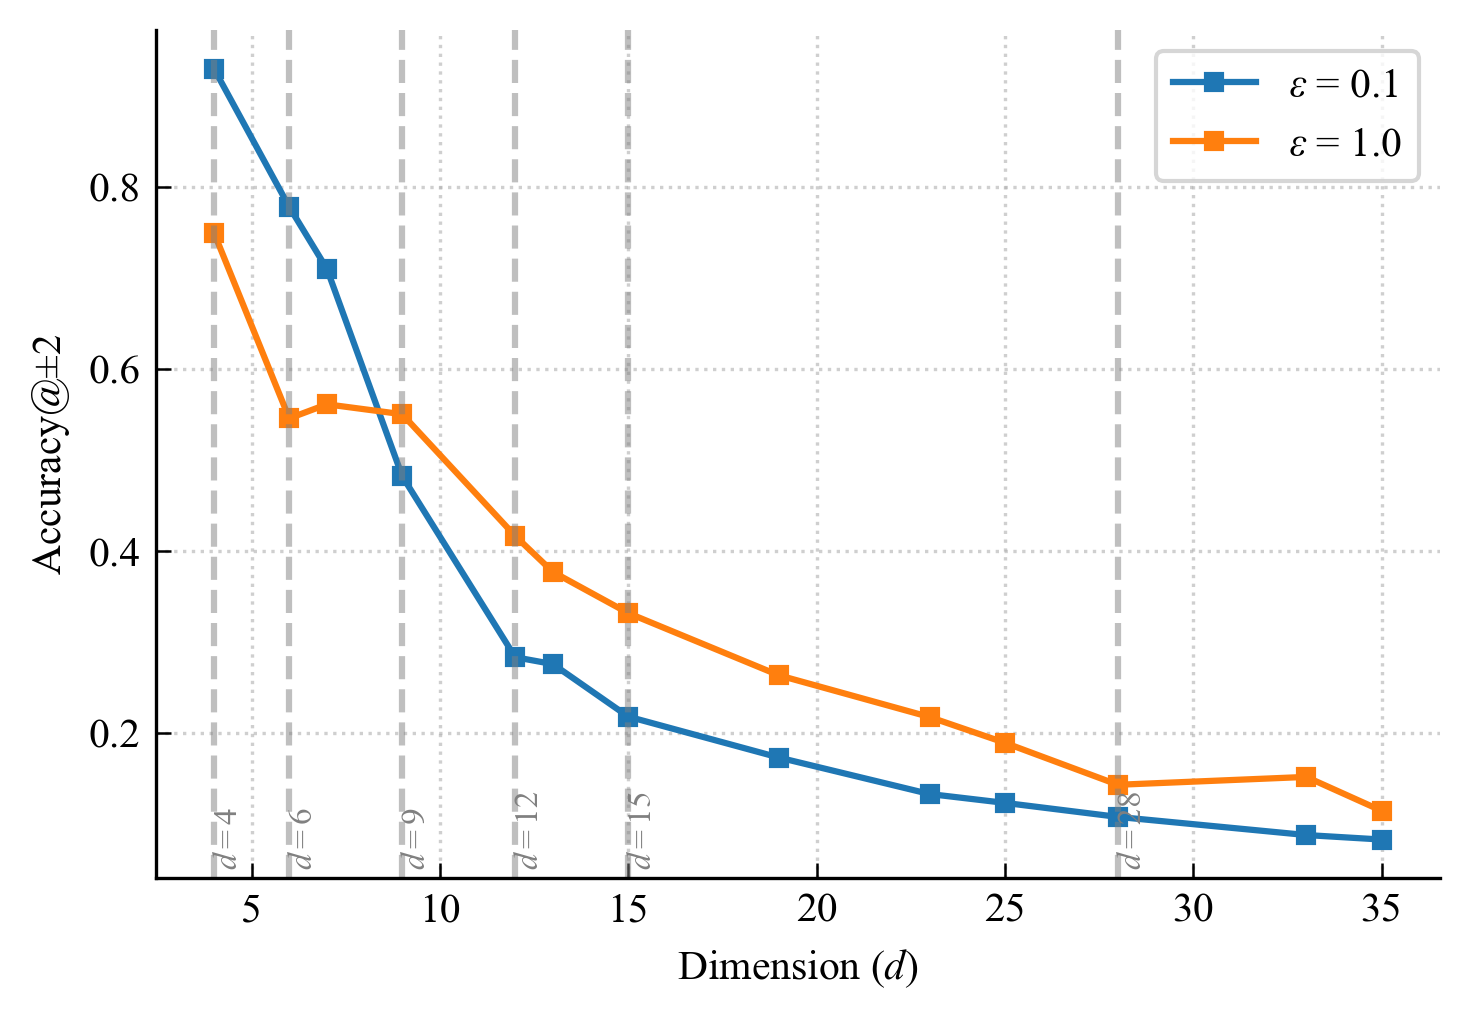

In [48]:
plot_model_results('./sandbox/jordan8_results', [0.1, 1.0], pretrained_dimensions, acc_within=2)

d = 12


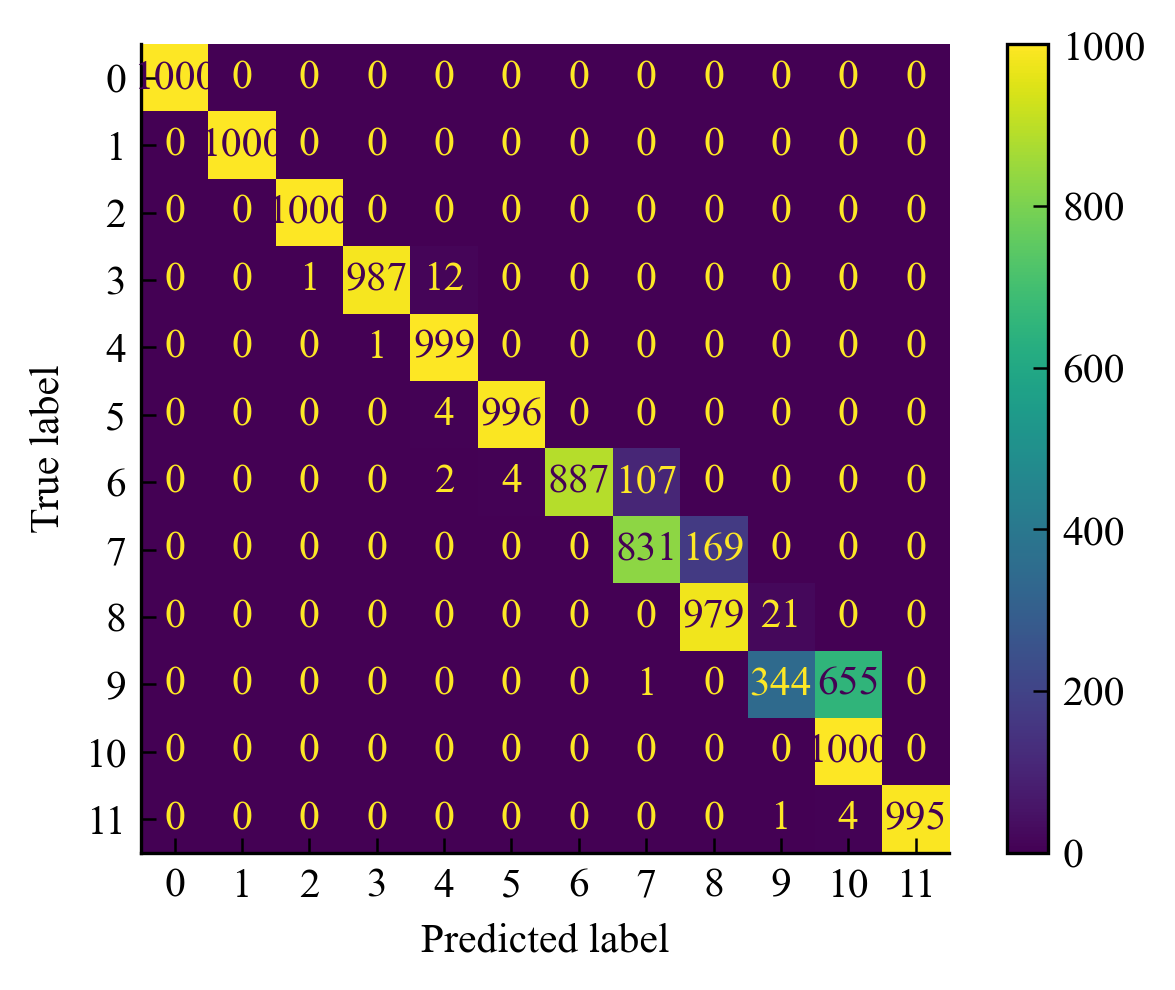

d = 13


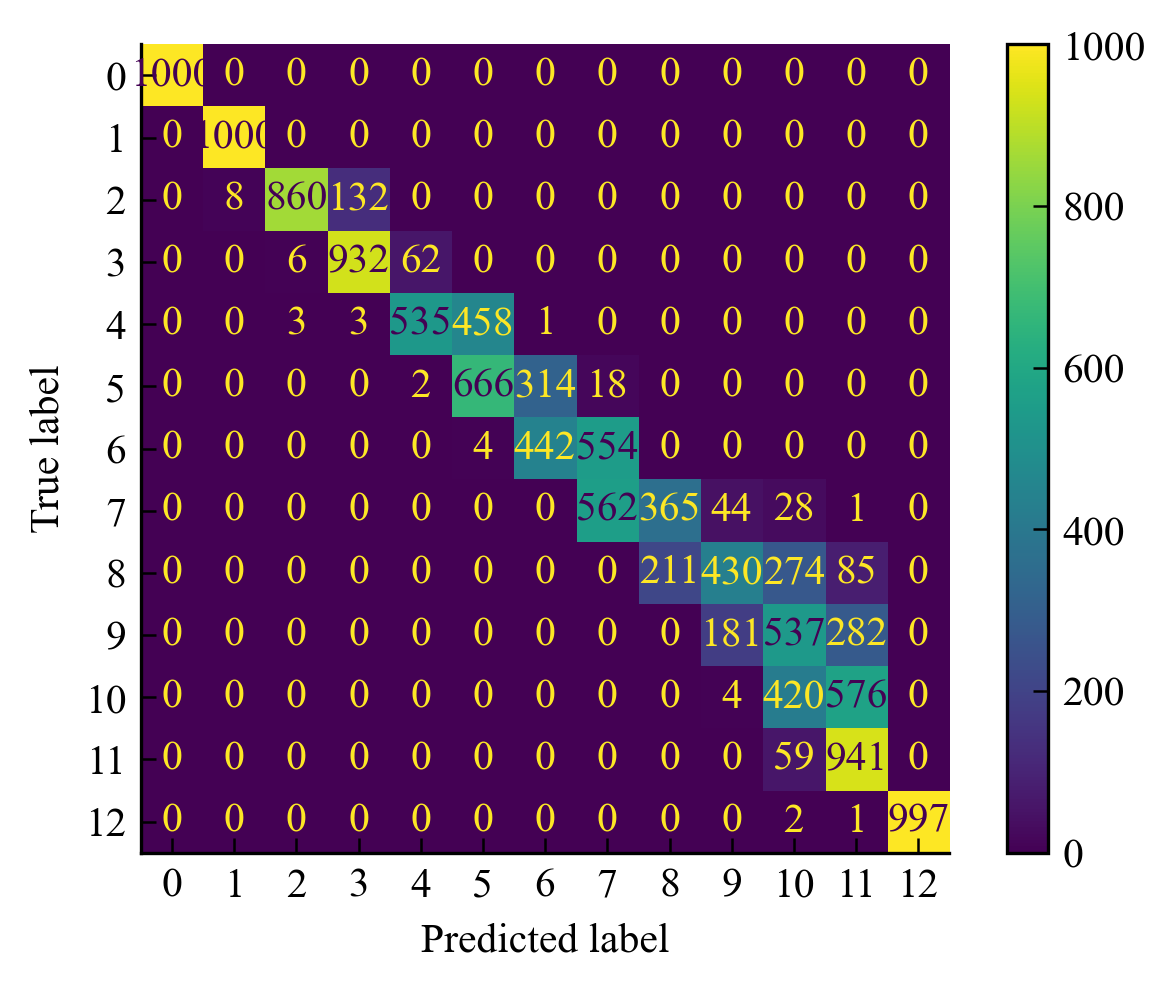

d = 15


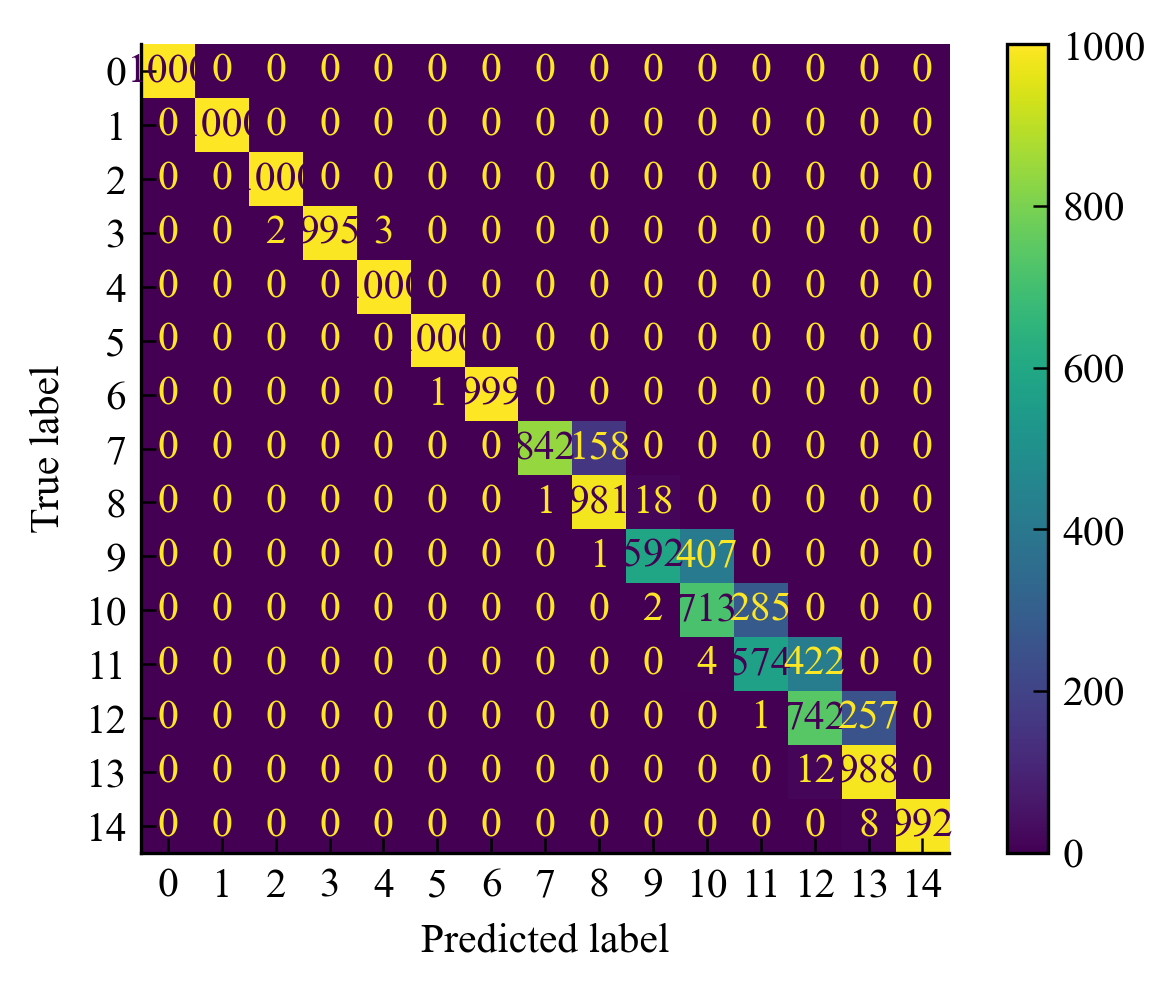

d = 19


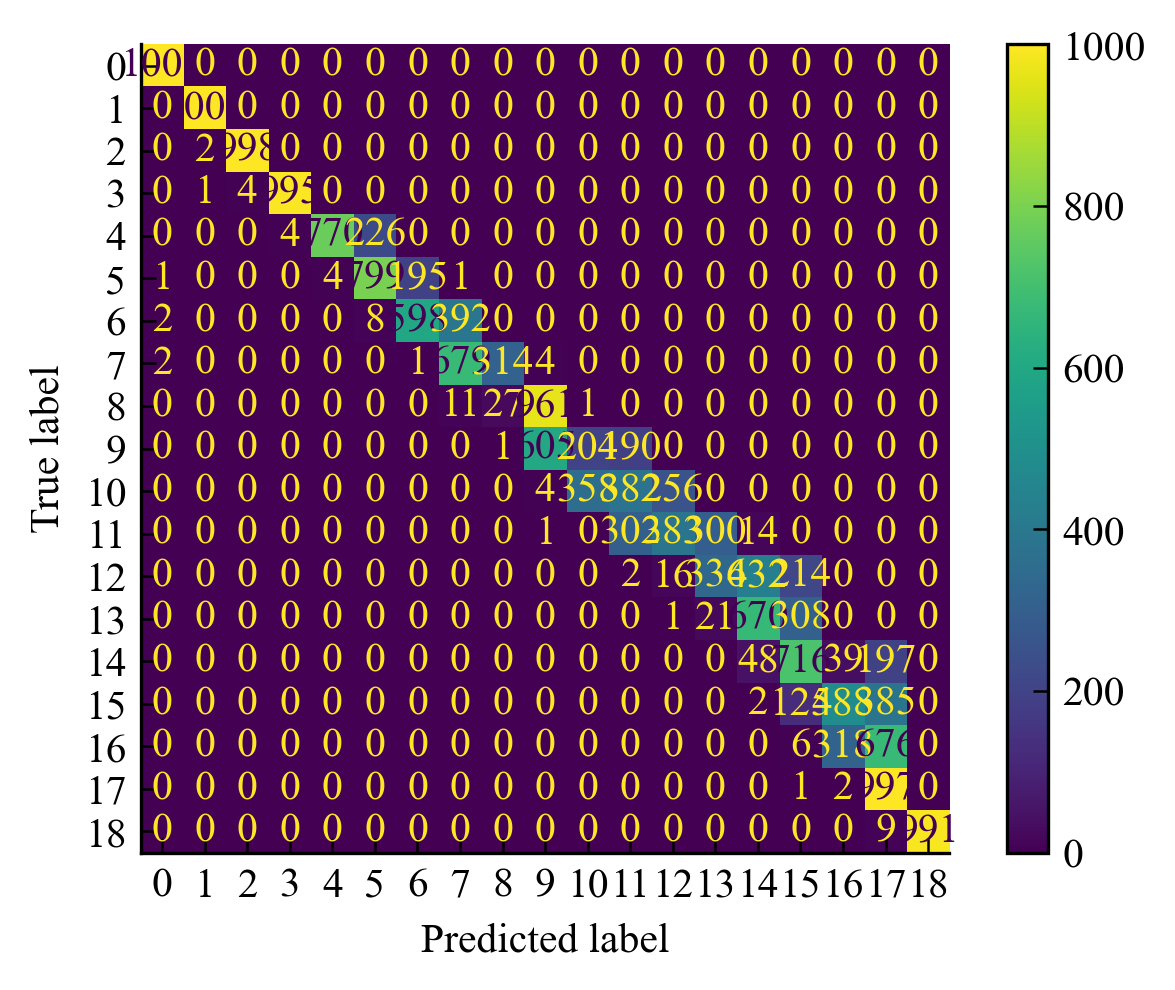

d = 23


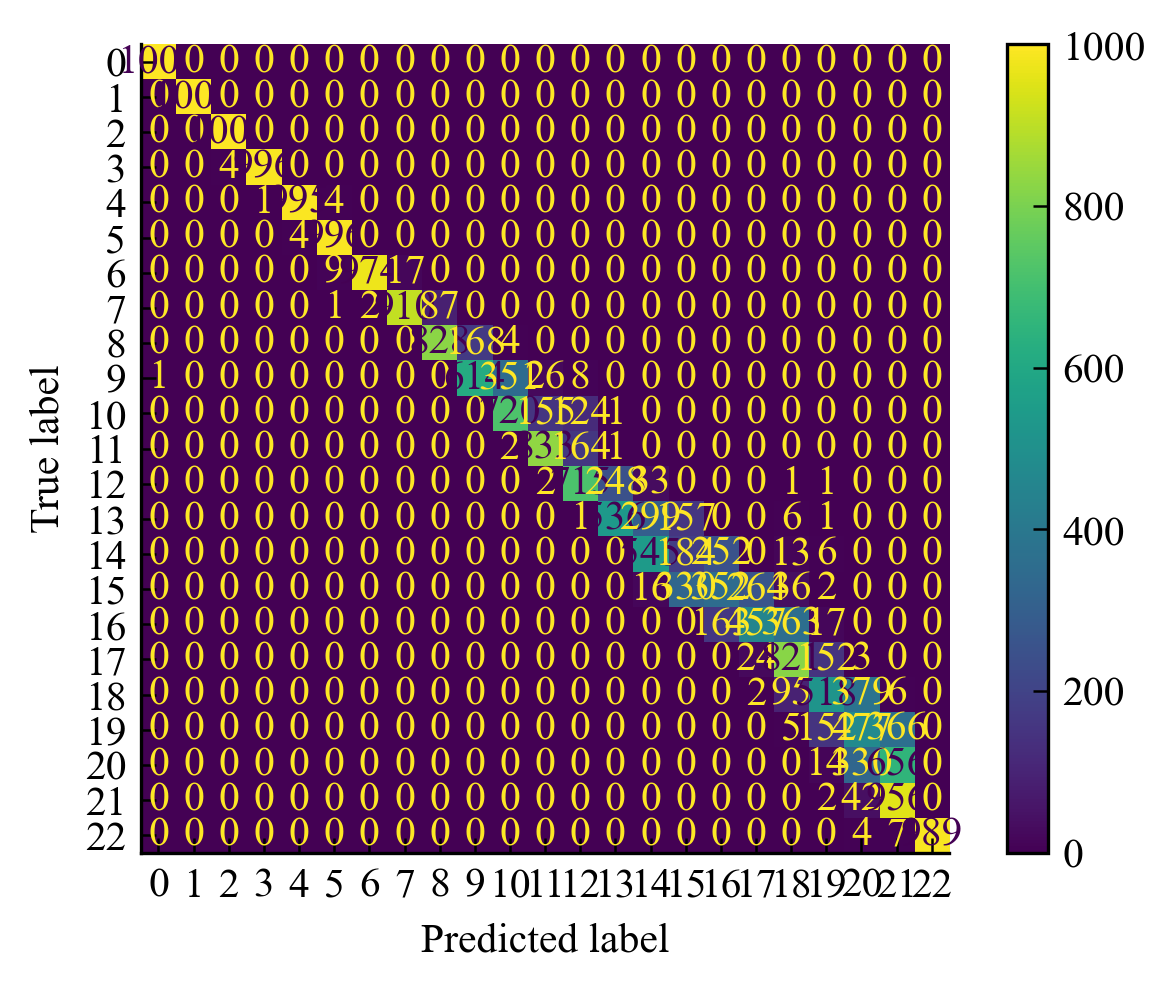

d = 25


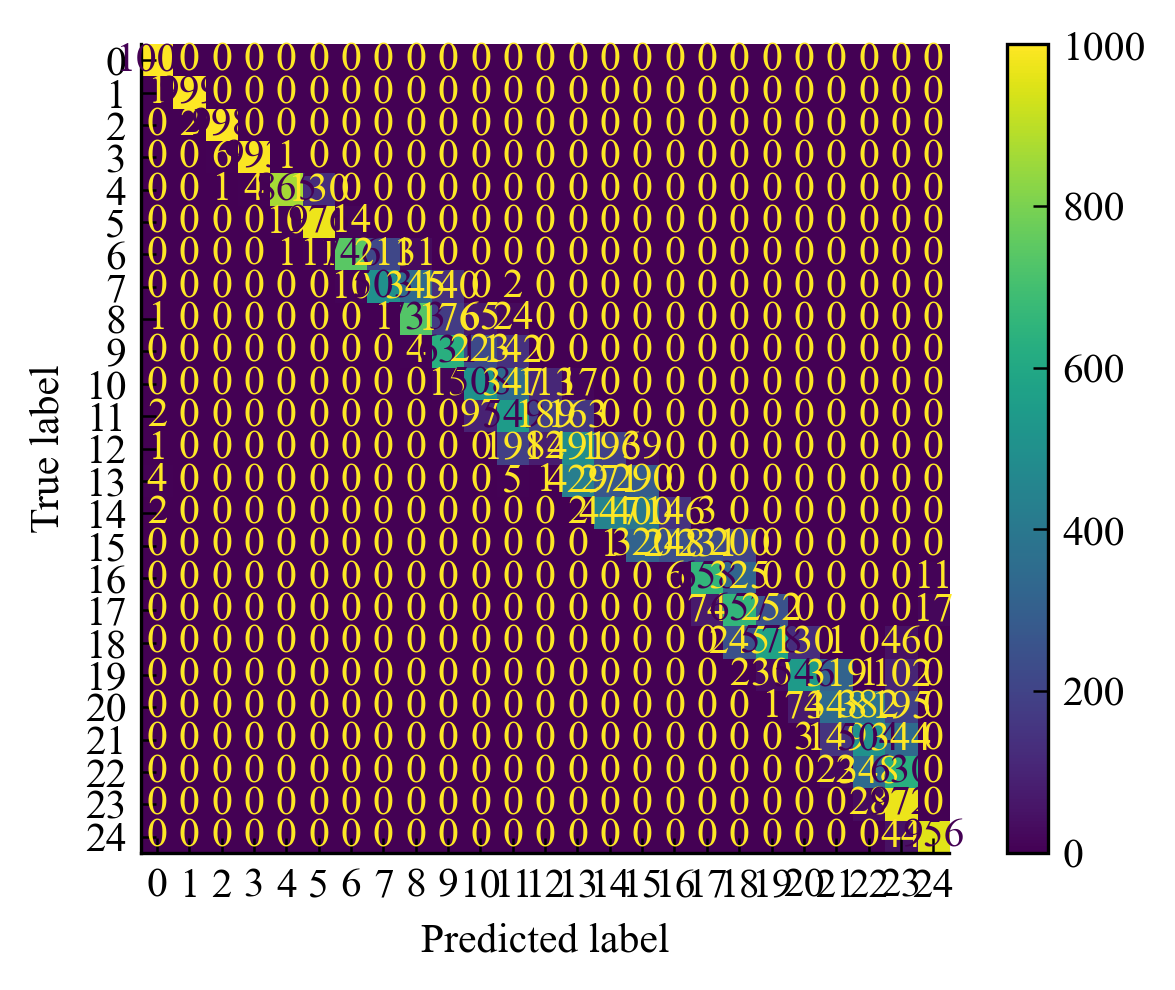

d = 28


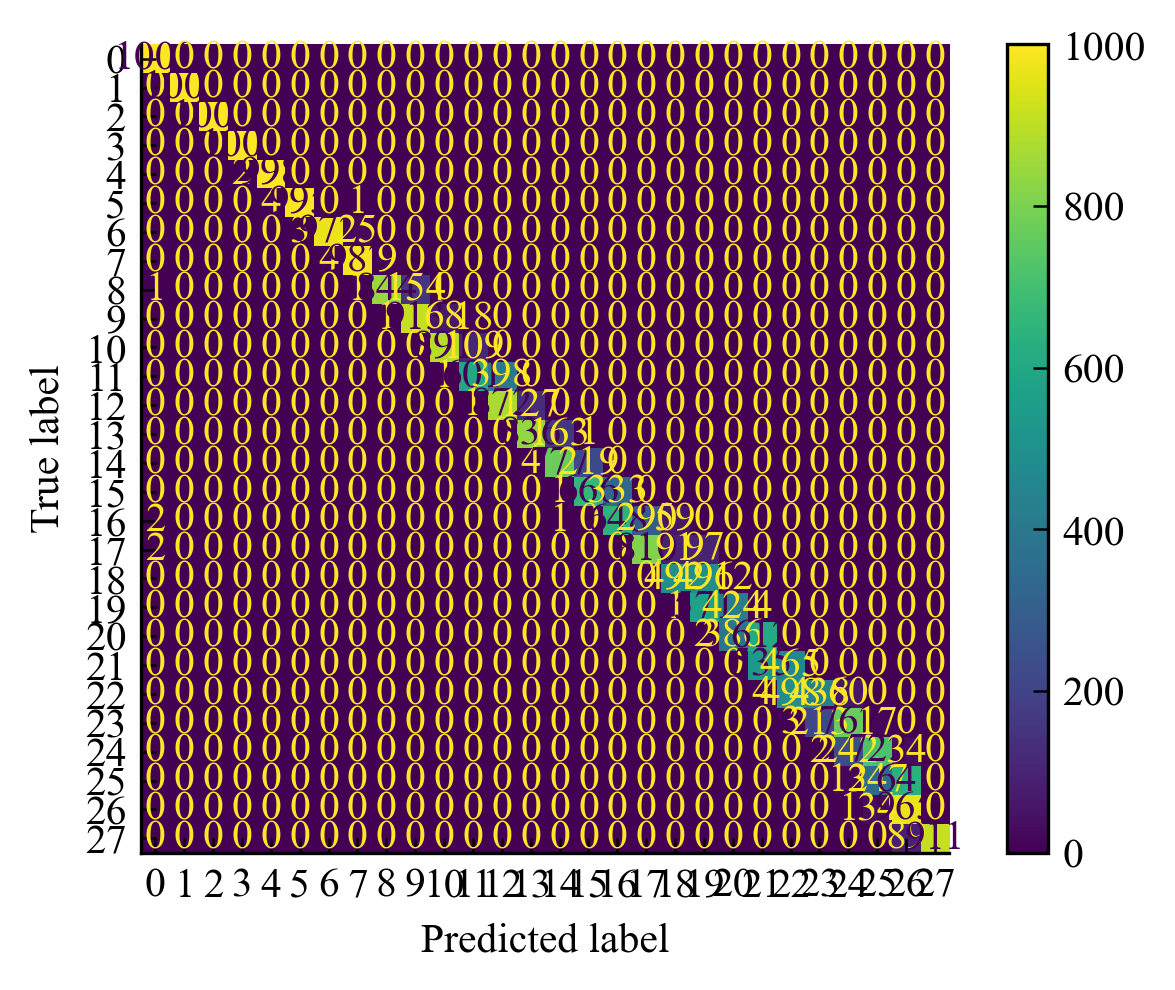

d = 33


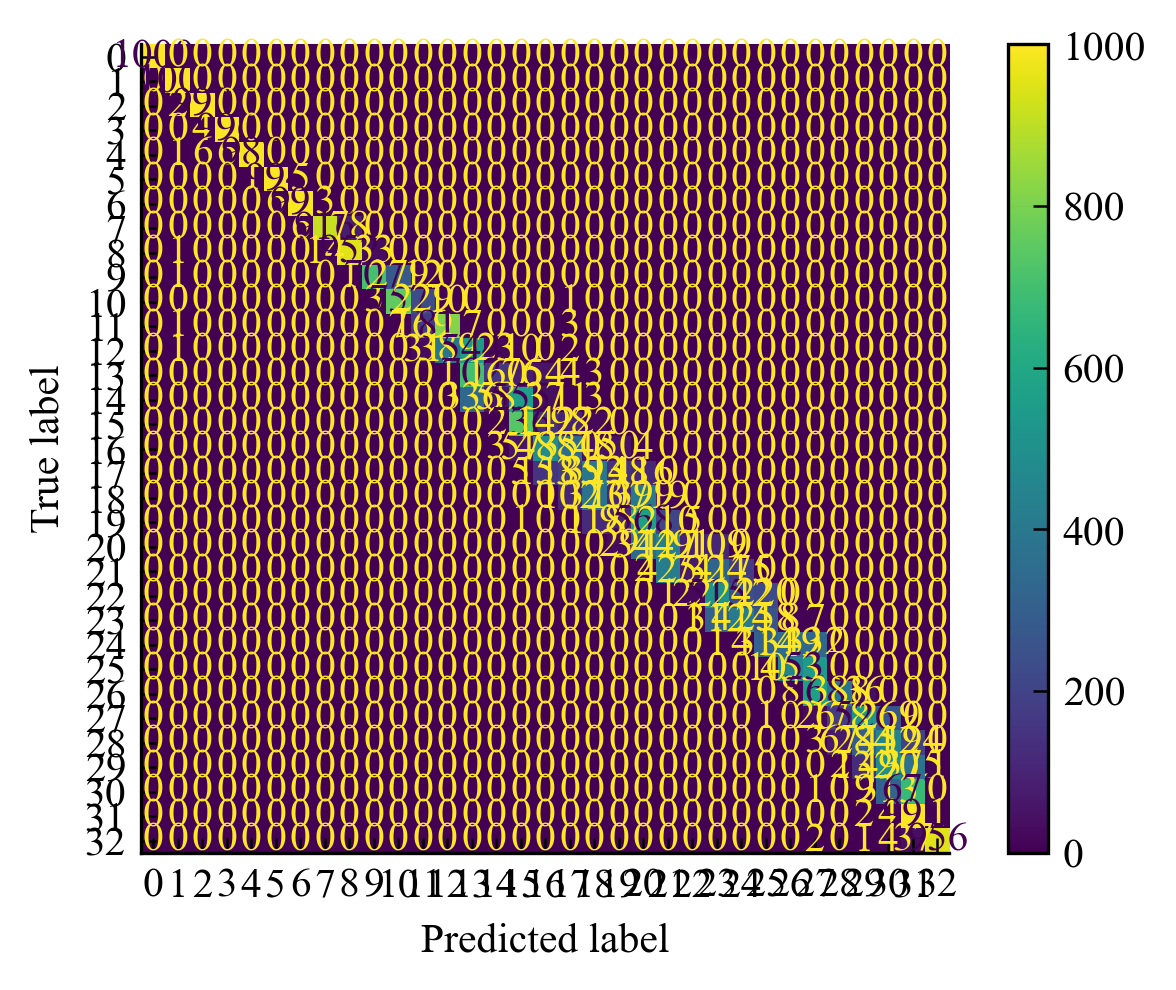

d = 35


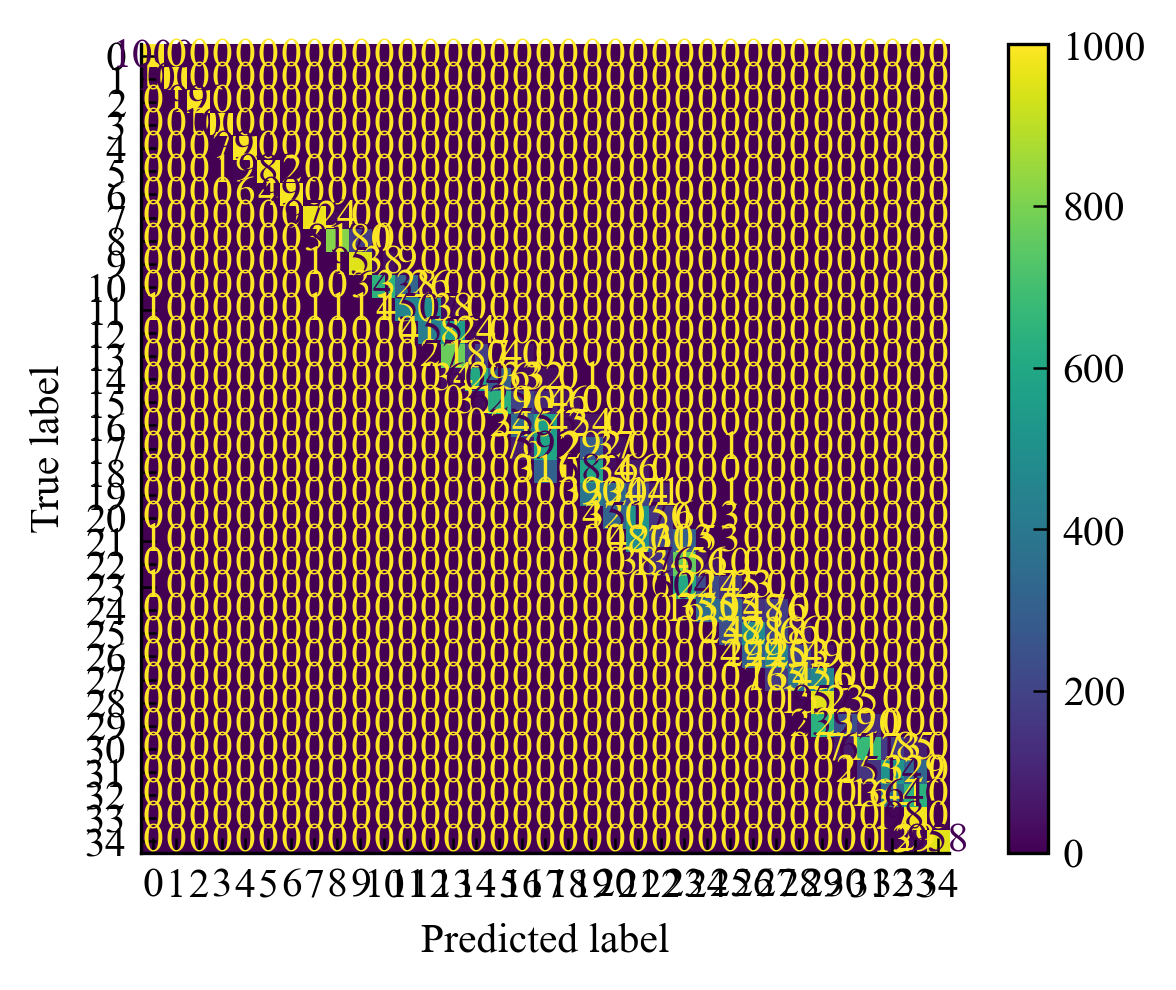

d = 4


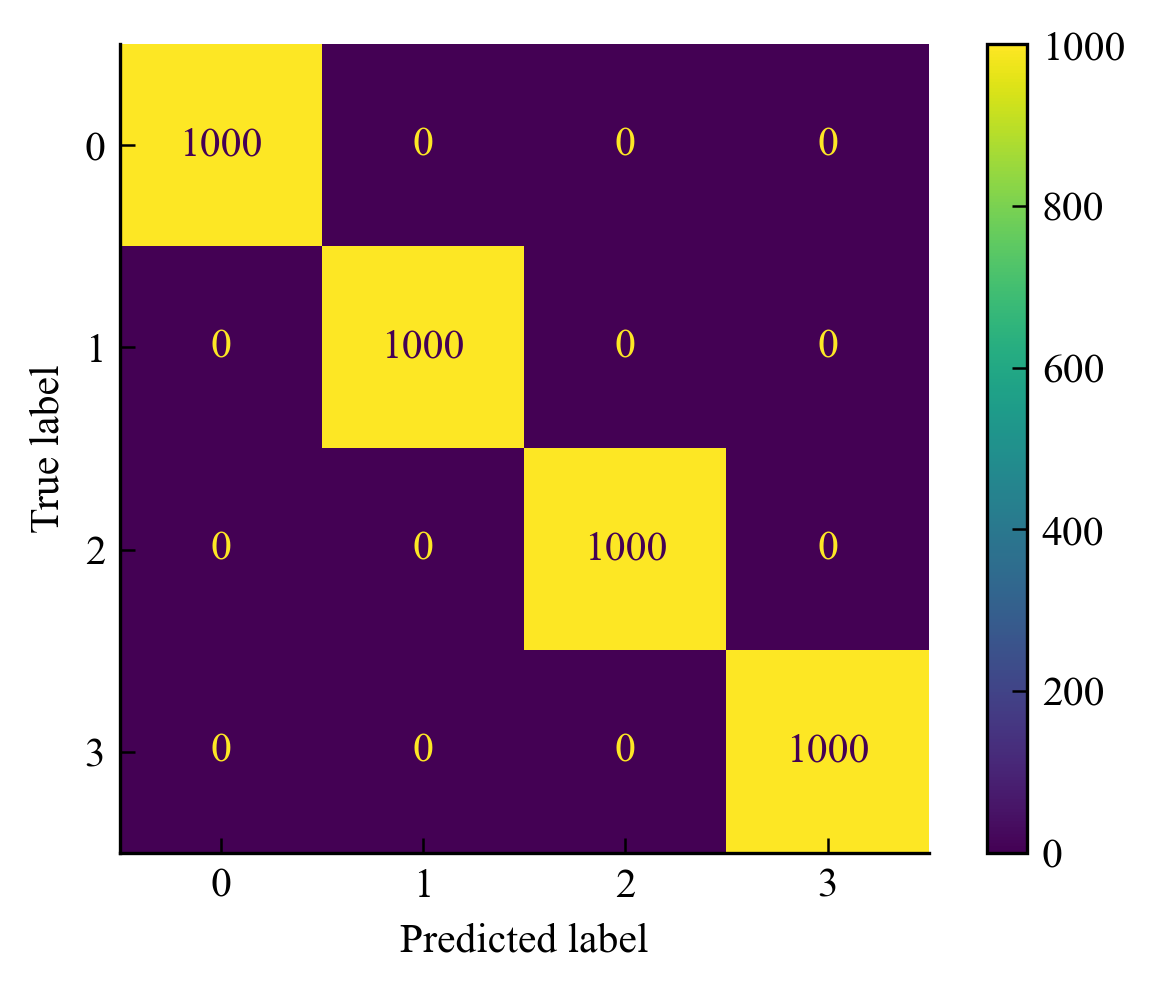

d = 6


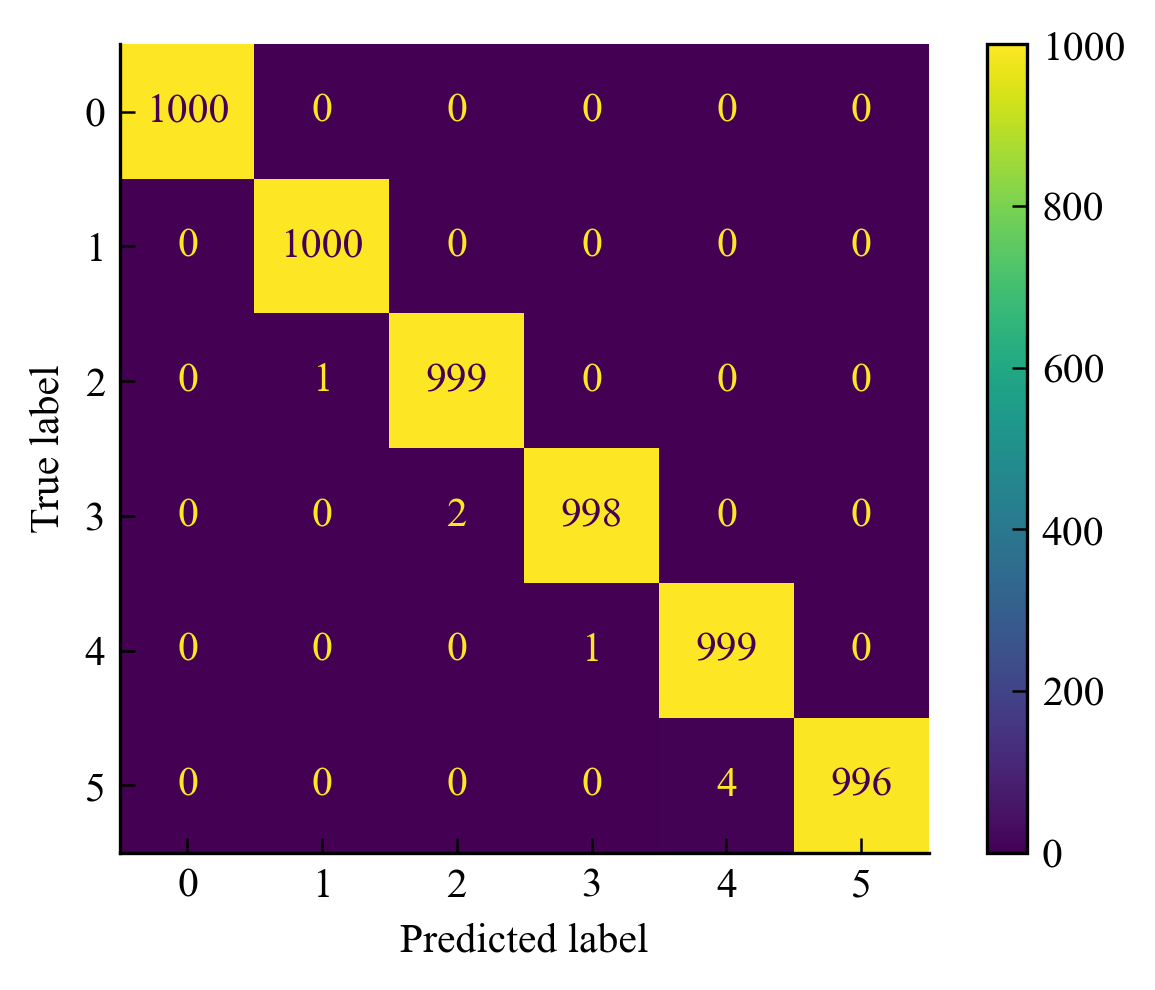

d = 7


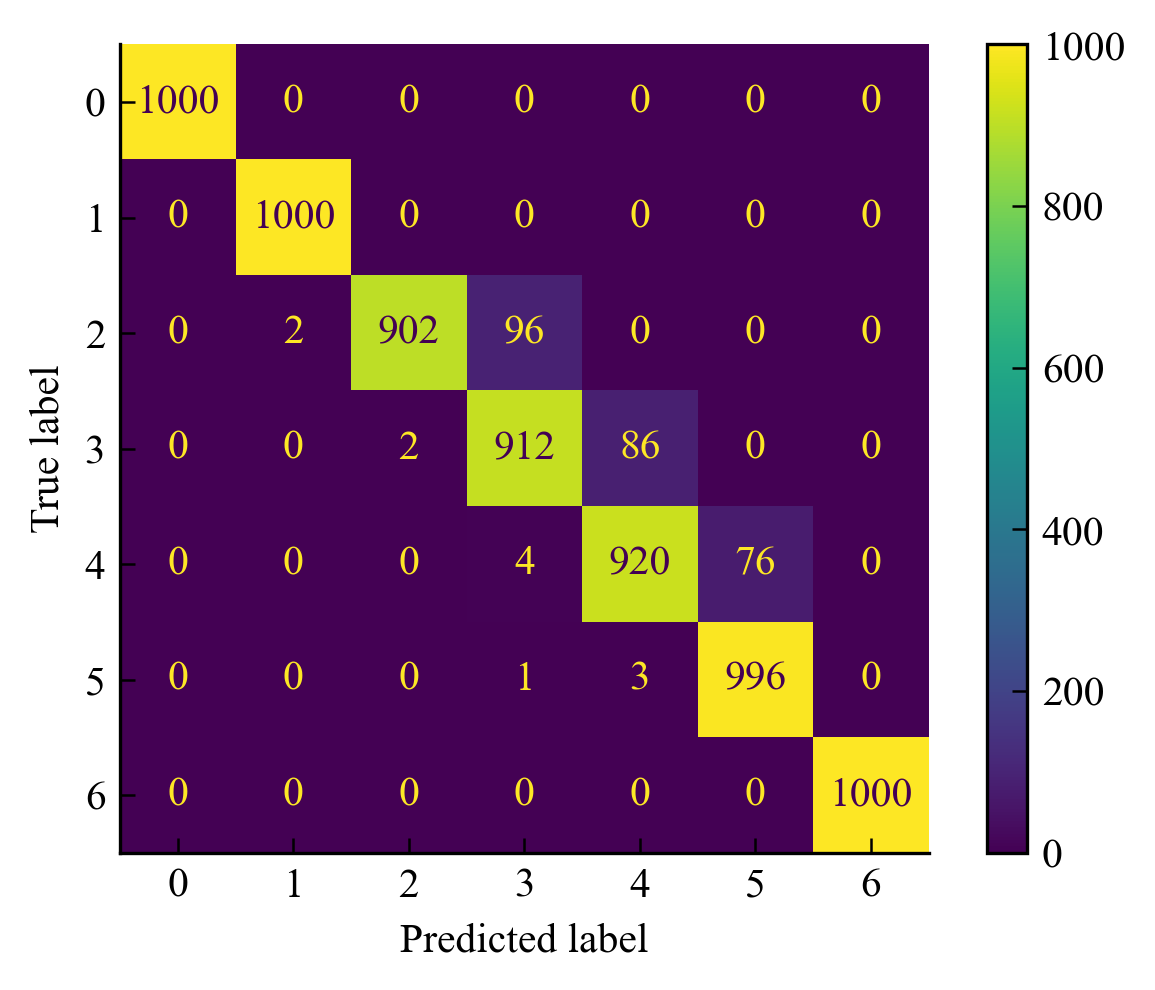

d = 9


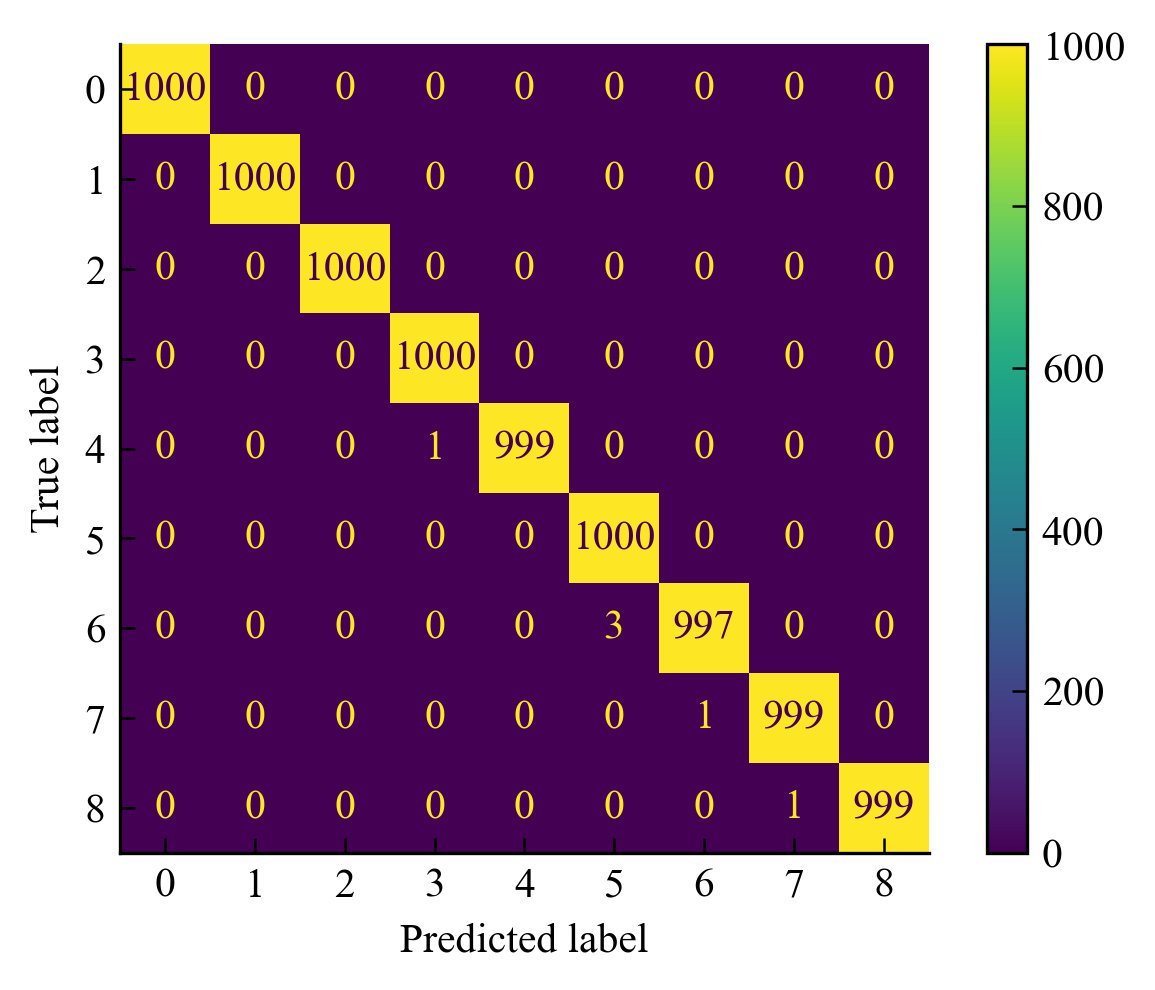

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for filename in os.listdir('./sandbox/jordan8_results'):
    if filename.startswith("results_") and filename.endswith(".json"):
        try:
            d = int(filename.split('_')[1].split('.')[0])
        except ValueError:
            continue
            
        file_path = os.path.join('./sandbox/jordan8_results', filename)
        with open(file_path, 'r') as f:
            results = json.load(f)
        
        for entry in results:
            curr_eps = entry.get("eps")
            if curr_eps == 0:
                print("d =", d)
                preds = entry.get("predicted_classes", [])
                trues = entry.get("true_classes", [])
                cm = confusion_matrix(trues, preds)
                ConfusionMatrixDisplay(cm).plot()
                plt.show()
